# Import

In [1]:
import numpy as np
import pandas as pd

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for _candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (_candidate / "config").is_dir() and (_candidate / "src").is_dir():
        PROJECT_ROOT = _candidate
        break
else:
    raise RuntimeError("could not find repository root (expected config/ and src/)")

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# Function test

In [2]:
from implied_volatility_diffusion.data import historical_data_smoothing_interpolation as hist_module

In [3]:
processed_data_path = PROJECT_ROOT / "data" / "processed" / "processed.parquet"
df = hist_module.load_cleaned_data(processed_data_path)
print("Data loaded, shape:", df.shape)

Data loaded, shape: (15409923, 26)


In [4]:
print(df.columns.tolist())
df.head()

['quote_date', 'expire_date', 'underlying_last', 'strike', 'dte', 'source_file', 'bid', 'ask', 'last', 'volume', 'iv', 'delta', 'gamma', 'vega', 'option_type', 'mid', 'spread', 'rel_spread', 'tau', 'moneyness', 'k', 'abs_k', 'total_variance', 'liq_weight', 'vega_weight', 'smooth_weight']


,quote_date,expire_date,underlying_last,strike,dte,source_file,bid,ask,last,volume,...,spread,rel_spread,tau,moneyness,k,abs_k,total_variance,liq_weight,vega_weight,smooth_weight
0,2019-01-02,2019-01-04,2509.98,2000.0,2.0,spx_eod_201901.txt,507.60,512.90,489.81,7.0,...,5.30,0.010387,0.005479,0.796819,-0.227128,0.227128,0.005016,96.273585,0.02672,2.572430
1,2019-01-02,2019-01-04,2509.98,2015.0,2.0,spx_eod_201901.txt,493.10,498.09,0.00,NaN,...,4.99,0.010069,0.005479,0.802795,-0.219656,0.219656,0.005728,99.317635,0.04855,4.821871
2,2019-01-02,2019-01-04,2509.98,2045.0,2.0,spx_eod_201901.txt,462.61,468.01,0.00,NaN,...,5.40,0.011605,0.005479,0.814748,-0.204877,0.204877,0.004327,86.168519,0.03215,2.770318
3,2019-01-02,2019-01-04,2509.98,2110.0,2.0,spx_eod_201901.txt,392.00,408.10,0.00,NaN,...,16.10,0.040245,0.005479,0.840644,-0.173587,0.173587,0.002350,24.847826,0.01141,0.283514
4,2019-01-02,2019-01-04,2509.98,2115.0,2.0,spx_eod_201901.txt,387.19,403.10,0.00,NaN,...,15.91,0.040264,0.005479,0.842636,-0.171220,0.171220,0.002728,24.836266,0.02351,0.583901


In [5]:
daily_counts = df.groupby("quote_date").size().rename("n_quotes").reset_index().sort_values("quote_date")

display(daily_counts.head())
display(daily_counts.tail())
display(daily_counts["n_quotes"].describe())

,quote_date,n_quotes
0,2019-01-02,9963
1,2019-01-03,10327
2,2019-01-04,10265
3,2019-01-07,10122
4,2019-01-08,9679


,quote_date,n_quotes
1243,2023-12-22,16153
1244,2023-12-26,15678
1245,2023-12-27,14430
1246,2023-12-28,14793
1247,2023-12-29,15388


count     1248.000000
mean     12347.694712
std       2035.890327
min       5655.000000
25%      10927.500000
50%      12663.000000
75%      13688.000000
max      17332.000000
Name: n_quotes, dtype: float64

In [6]:
sample_date = pd.Timestamp("2021-06-17")
day = df[df["quote_date"] == sample_date].copy()

print("sample_date:", sample_date)
print("rows on sample day:", len(day))

display(day[["tau", "moneyness", "k", "iv", "vega", "smooth_weight"]].describe())

sample_date: 2021-06-17 00:00:00
rows on sample day: 14699


,tau,moneyness,k,iv,vega,smooth_weight
count,14699.000000,14699.000000,14699.000000,14699.000000,14699.000000,14695.000000
mean,0.352917,0.907215,-0.131126,0.306381,3.358796,393.787747
std,0.489494,0.200242,0.296649,0.317996,66.401302,660.202608
min,0.002740,0.023686,-3.742866,0.057800,-6741.259460,0.000445
25%,0.052055,0.812434,-0.207720,0.146730,0.573205,14.854091
50%,0.175342,0.929681,-0.072914,0.222090,2.585230,118.976030
75%,0.454904,1.017319,0.017171,0.326230,6.358580,387.387409
max,2.496000,1.752774,0.561199,2.983400,26.220070,3881.669938


In [7]:
k_grid = np.linspace(-0.5, 0.4, 60)
tau_grid = np.linspace(0.01, 2.0, 60)
KGRID, TAUGRID = np.meshgrid(k_grid, tau_grid, indexing="ij")

print(KGRID.shape, TAUGRID.shape)

(60, 60) (60, 60)


In [8]:
Z_vega, day_sub = hist_module.build_kernel_surface(
    day,
    x_col="k",
    weight_col="vega",
    x_grid=k_grid,
    tau_grid=tau_grid,
    h1=0.01,
    h2=0.10,
    clip_upper=50,
    sqrt_weight=False,
)

print("filtered rows used:", len(day_sub))
print("surface shape:", Z_vega.shape)
print("finite values:", np.isfinite(Z_vega).sum())

filtered rows used: 12812
surface shape: (60, 60)
finite values: 3600


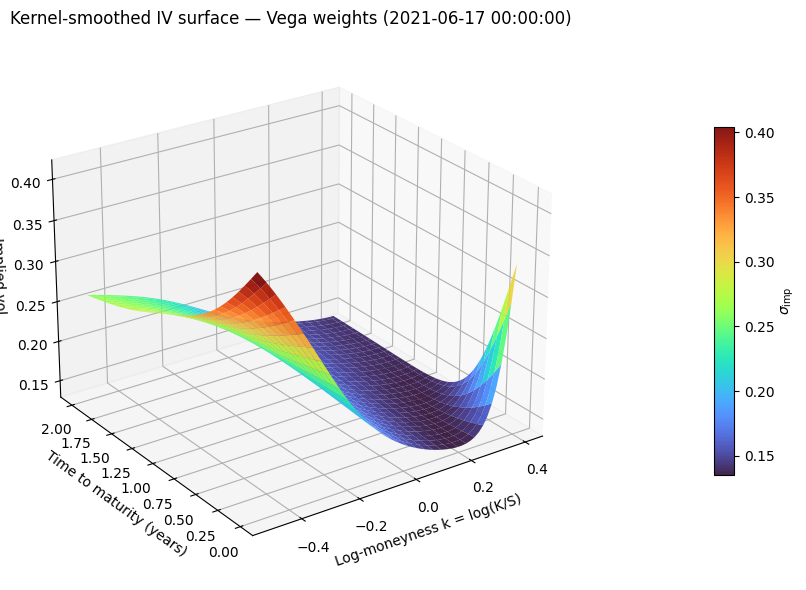

In [9]:
hist_module.plot_surface_3d(KGRID, TAUGRID, Z_vega, sample_date, title="Kernel-smoothed IV surface — Vega weights")

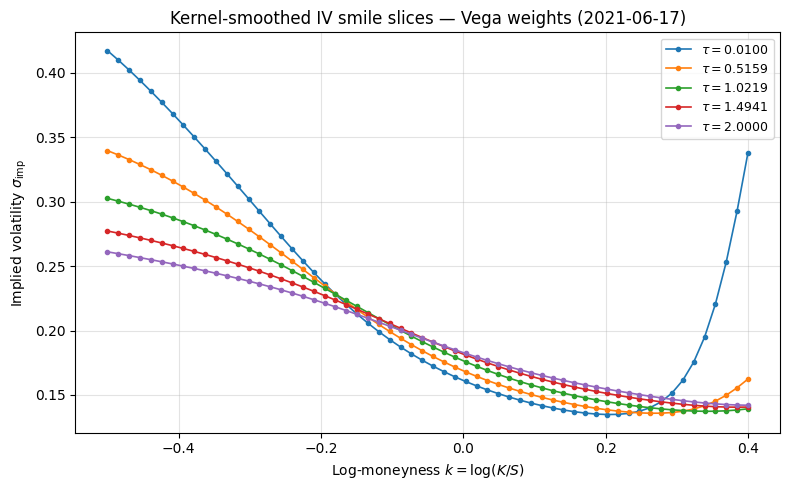

In [10]:
hist_module.plot_smile(k_grid, tau_grid, Z_vega, sample_date, title="Kernel-smoothed IV smile slices — Vega weights")

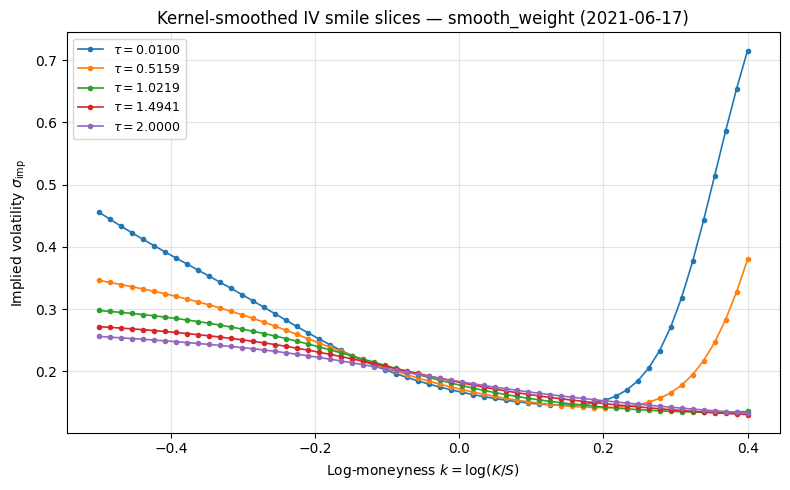

In [11]:
Z_sw, day_sub_sw = hist_module.build_kernel_surface(
    day,
    x_col="k",
    weight_col="smooth_weight",
    x_grid=k_grid,
    tau_grid=tau_grid,
    h1=0.01,
    h2=0.10,
    clip_upper=500,
    sqrt_weight=False,
)

hist_module.plot_smile(k_grid, tau_grid, Z_sw, sample_date, title="Kernel-smoothed IV smile slices — smooth_weight")

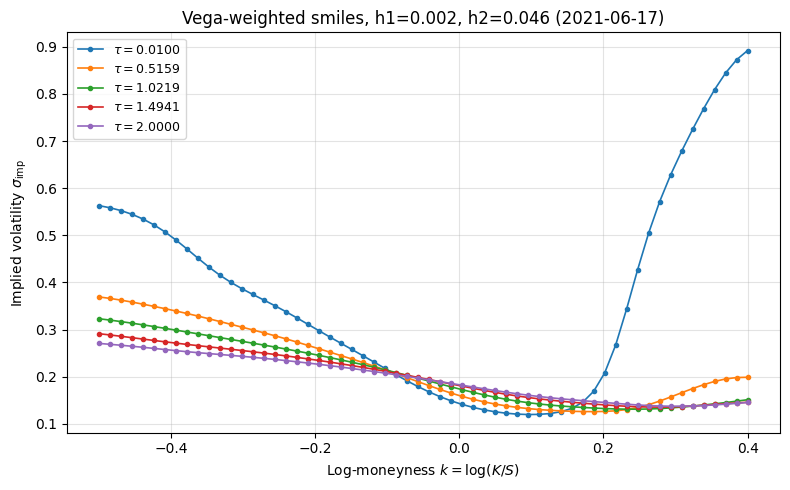

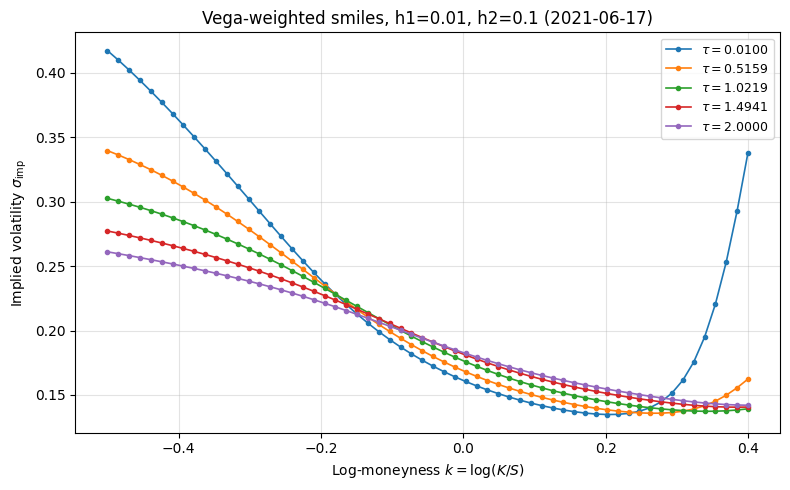

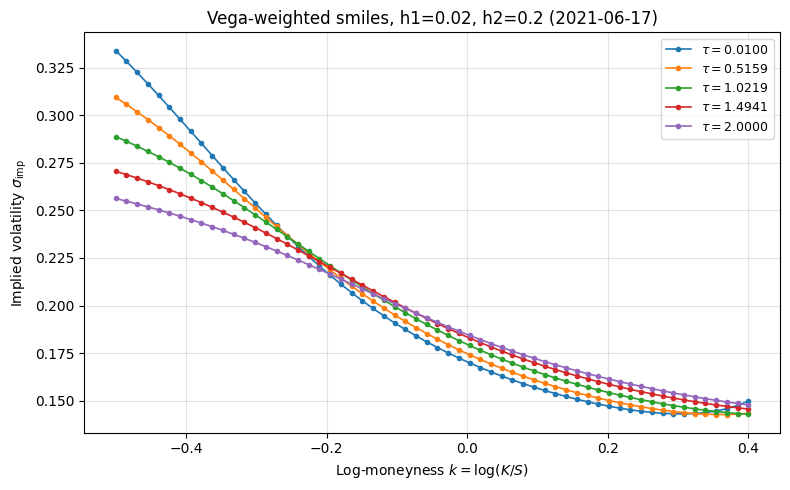

In [12]:
bandwidths = [
    (0.002, 0.046),
    (0.01, 0.10),
    (0.02, 0.20),
]

for h1, h2 in bandwidths:
    Z_test, _ = hist_module.build_kernel_surface(
        day,
        x_col="k",
        weight_col="vega",
        x_grid=k_grid,
        tau_grid=tau_grid,
        h1=h1,
        h2=h2,
        clip_upper=50,
        sqrt_weight=False,
    )

    hist_module.plot_smile(k_grid, tau_grid, Z_test, sample_date, title=f"Vega-weighted smiles, h1={h1}, h2={h2}")